# Integración de Datos – Entidad Prestadora de Salud

En este espacio de trabajo se plantea como caso de estudio un proceso de integración de datos aplicado a una entidad prestadora de salud, bajo el enfoque de la Teoría de la Credibilidad y métodos de integración basados en aceptación y rechazo.

La entidad prestadora de salud busca mejorar la eficiencia en la prestación de sus servicios, para lo cual se plantea el cierre de una de sus sucursales. Con el fin de tomar una decisión informada y minimizar el impacto en la atención de los pacientes, se propone realizar un proceso de análisis e integración de datos que permita identificar la sucursal con mayor afinidad con la sucursal que se desea cerrar, ubicada en Sabaneta.

El proceso de análisis toma como variable de referencia la información relacionada con los pacientes diagnosticados con diabetes, la cual se utilizará para evaluar la similitud entre las diferentes sucursales y determinar cuál de ellas presenta mayor afinidad con la sucursal que se planea cerrar.

En primer lugar, se realiza un análisis estadístico de cada una de las bases de datos correspondientes a las sucursales, utilizando medidas de tendencia central y de dispersión. Este análisis permite comprender el comportamiento de la variable de referencia y establecer comparaciones entre las distintas sucursales, tanto antes como después de la integración de los datos de nuevos pacientes.

Posteriormente, se aplica la Teoría de la Credibilidad con el objetivo de estimar el grado de afinidad entre la sucursal que se desea cerrar y las demás sucursales. A partir de las medidas de tendencia central y dispersión, se determina el peso relativo de la información proveniente de cada sucursal, permitiendo identificar aquella que presenta mayor similitud con la sucursal de Sabaneta.

Una vez identificada la sucursal con mayor afinidad, se procede a realizar la clasificación de los pacientes en las demás sucursales mediante el método del valor de pertenencia. Este método permite asignar a los pacientes a la sucursal más adecuada de acuerdo con el comportamiento de la variable de referencia analizada.

Debido a que la entidad prestadora de salud desea comparar distintos enfoques de integración, el mismo procedimiento se realiza también mediante el método de aceptación y rechazo. Este método agrupa diferentes técnicas de integración basadas en la estructura intrínseca de las variables de referencia, permitiendo validar o contrastar los resultados obtenidos mediante el método de valor de pertenencia.

Finalmente, antes y después del proceso de integración de los pacientes en las nuevas sucursales, se lleva a cabo nuevamente un análisis estadístico basado en medidas de tendencia central y dispersión, con el fin de evaluar los cambios generados en las bases de datos y analizar el impacto del proceso de redistribución de pacientes.

Los datos utilizados para el desarrollo del caso provienen del archivo 3. Parcial - medical_attention_data.xlsx, el cual contiene la información necesaria para realizar el proceso de análisis, estimación de credibilidad e integración de pacientes entre las distintas sucursales.

0. Se procede con la carga de las librerias de trabajo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.cluster.hierarchy import linkage, dendrogram

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Se carga el archivo desde Google Drive y se leen todas las hojas

In [3]:
file = "/content/drive/MyDrive/integración de datos y prospectiva/Reto 3/3. Parcial - medical_attention_data.xlsx"

data = pd.read_excel(file, sheet_name=None)

bello = data["Bello"]
medellin = data["Medellín"]
envigado = data["Envigado"]
itagui = data["Itagui"]
sabaneta = data["Sabaneta"]
caldas = data["Caldas"]

sabaneta.head()

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,SAB-0001,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,SAB-0002,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,SAB-0003,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,SAB-0004,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,SAB-0005,189,47,22,600,24.747,0.993,43,1,Sabaneta


In [4]:
print("Bello:", bello.columns)
print("Medellin:", medellin.columns)
print("Envigado:", envigado.columns)
print("Itagui:", itagui.columns)
print("Sabaneta:", sabaneta.columns)
print("Caldas:", caldas.columns)

Bello: Index(['PatientID', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetes', 'Branch'],
      dtype='object')
Medellin: Index(['PatientID', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetes',
       'Branch'],
      dtype='object')
Envigado: Index(['PatientID', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetes', 'Branch'],
      dtype='object')
Itagui: Index(['PatientID', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Diabetes', 'Branch'],
      dtype='object')
Sabaneta: Index(['PatientID', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetes', 'Branch'],
      dtype='object')
Caldas: Index(['PatientID', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BM

2. Se seleccionan los pacientes con diabetes

In [5]:
sabaneta_d = sabaneta[sabaneta["Diabetes"] == 1].copy()
bello_d = bello[bello["Diabetes"] == 1]
medellin_d = medellin[medellin["Diabetes"] == 1]
envigado_d = envigado[envigado["Diabetes"] == 1]
itagui_d = itagui[itagui["Diabetes"] == 1]
caldas_d = caldas[caldas["Diabetes"] == 1]

3. Medidas de tendencia central y dispersión

Definir variables comunes:

Se eliminan:


*   Glucose
*   Pregnancies
*   PatientID
*   Branch

In [7]:
variables = ["BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]

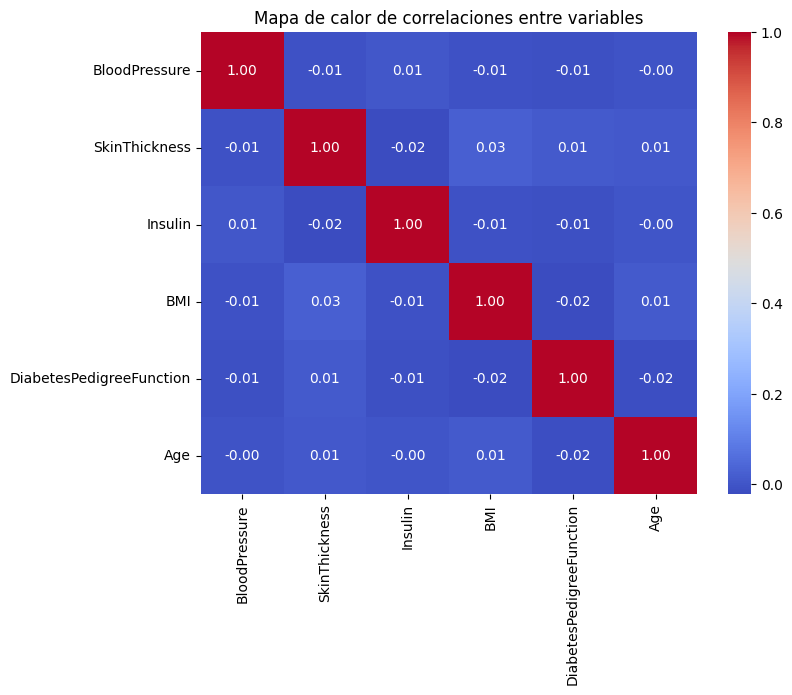

In [8]:
todas_sucursales = pd.concat([
    bello,
    medellin,
    envigado,
    itagui,
    sabaneta,
    caldas
])

correlaciones = todas_sucursales[variables].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de calor de correlaciones entre variables")

plt.show()

In [9]:
variable = ["BMI"]

Función para estadísticas:

In [10]:
def estadisticas(df):
    return df[variable].agg(['mean','std','var'])

print("Sabaneta")
print(estadisticas(sabaneta_d))

print("Bello")
print(estadisticas(bello_d))

print("Medellín")
print(estadisticas(medellin_d))

print("Envigado")
print(estadisticas(envigado_d))

print("Itagui")
print(estadisticas(itagui_d))

print("Caldas")
print(estadisticas(caldas_d))

Sabaneta
            BMI
mean  33.325779
std    9.957656
var   99.154922
Bello
            BMI
mean  32.691358
std    9.806549
var   96.168404
Medellín
             BMI
mean   32.908611
std    10.055997
var   101.123078
Envigado
            BMI
mean  32.287875
std    9.806150
var   96.160582
Itagui
            BMI
mean  31.858139
std    9.821171
var   96.455395
Caldas
             BMI
mean   32.694925
std    10.108580
var   102.183386


4. Teoría de la Credibilidad

In [11]:
def credibilidad(base_ref, base_comp):

    media_ref = base_ref[variables].mean()
    media_comp = base_comp[variables].mean()

    var_ref = base_ref[variables].var()

    Z = 1 / (1 + abs(media_ref - media_comp) / var_ref)

    return Z.mean()

5. Calcular credibilidad respecto a Sabaneta

In [12]:
cred_bello = credibilidad(sabaneta_d, bello_d)
cred_medellin = credibilidad(sabaneta_d, medellin_d)
cred_envigado = credibilidad(sabaneta_d, envigado_d)
cred_itagui = credibilidad(sabaneta_d, itagui_d)
cred_caldas = credibilidad(sabaneta_d, caldas_d)

print("Credibilidad Bello:", cred_bello)
print("Credibilidad Medellín:", cred_medellin)
print("Credibilidad Envigado:", cred_envigado)
print("Credibilidad Itagui:", cred_itagui)
print("Credibilidad Caldas:", cred_caldas)

Credibilidad Bello: 0.9811055881104184
Credibilidad Medellín: 0.9869137051220048
Credibilidad Envigado: 0.9876342799405607
Credibilidad Itagui: 0.9783256685918861
Credibilidad Caldas: 0.9846409407137887


6. Identificar sucursal con mayor afinidad

In [13]:
credibilidad_sucursales = {
    "Bello": cred_bello,
    "Medellin": cred_medellin,
    "Envigado": cred_envigado,
    "Itagui": cred_itagui,
    "Caldas": cred_caldas
}

afin = max(credibilidad_sucursales, key=credibilidad_sucursales.get)

print("Sucursal con mayor afinidad con Sabaneta:", afin)

Sucursal con mayor afinidad con Sabaneta: Envigado


Los resultados de la Teoría de la Credibilidad muestran que todas las sucursales presentan valores muy altos (superiores a 0.97), lo que indica que los pacientes de estas sedes tienen características muy similares a las de la sucursal de Sabaneta. Entre ellas, Envigado presenta la mayor credibilidad (0.9876), seguida de Medellín (0.9869) y Caldas (0.9846), mientras que Bello (0.9811) e Itagüí (0.9783) también muestran niveles elevados de afinidad. Esto sugiere que la sucursal de Envigado es la más similar a Sabaneta, por lo que sería la alternativa más adecuada para absorber principalmente a los pacientes tras el cierre de esta sucursal.

7. Método de Valor de Pertenencia

Calcular medias de sucursales:

In [15]:
medias = {
"Bello": bello_d[variable].mean(),
"Medellin": medellin_d[variable].mean(),
"Envigado": envigado_d[variable].mean(),
"Itagui": itagui_d[variable].mean(),
"Caldas": caldas_d[variable].mean()
}

Función de pertenencia:

In [16]:
def valor_pertenencia(paciente, medias):

    distancia = np.linalg.norm(paciente[variable] - medias)

    return 1 / (1 + distancia)

Clasificación de pacientes de Sabaneta:

In [17]:
asignacion = []

for i,row in sabaneta_d.iterrows():

    paciente = row

    pertenencias = {k:valor_pertenencia(paciente,v) for k,v in medias.items()}

    sucursal = max(pertenencias,key=pertenencias.get)

    asignacion.append(sucursal)

sabaneta_d["NuevaSucursal"] = asignacion

8. Método de Aceptación y Rechazo

In [20]:
np.random.seed(42)

def aceptacion_rechazo(paciente):

    sucursales = list(medias.keys())

    while True:

        sucursal = random.choice(sucursales)

        media = medias[sucursal]

        distancia = np.linalg.norm(paciente[variable] - media)

        prob = np.exp(-distancia/100)

        u = random.random()

        if u < prob:
            return sucursal

Aplicar método:

In [21]:
asignacion_ar = []

for i,row in sabaneta_d.iterrows():

    sucursal = aceptacion_rechazo(row)

    asignacion_ar.append(sucursal)

sabaneta_d["Sucursal_AR"] = asignacion_ar

9. Integración final de pacientes

In [22]:
integrado = pd.concat([bello,medellin,envigado,itagui,caldas,sabaneta_d])

10. Estadísticas después de la integración

In [24]:
integrado[variable].describe()

,BMI
count,4099.000000
mean,32.798371
std,9.984774
min,15.000000
25%,24.210500
50%,33.097000
75%,41.122500
max,49.993000


11. Comparación antes vs después

In [25]:
sabaneta[variable].describe()

,BMI
count,621.000000
mean,32.992060
std,9.894817
min,15.003000
25%,24.478000
50%,32.923000
75%,41.537000
max,49.944000


In [26]:
integrado[variable].describe()

,BMI
count,4099.000000
mean,32.798371
std,9.984774
min,15.000000
25%,24.210500
50%,33.097000
75%,41.122500
max,49.993000


El análisis de las estadísticas descriptivas muestra que, tras el cierre de la sucursal de Sabaneta y la integración de sus pacientes en las demás sucursales (Bello, Envigado, Medellín, Itagüí y Caldas), el número total de registros aumenta significativamente. Sin embargo, las medidas de tendencia central y dispersión presentan cambios mínimos en la mayoría de las variables. Esto indica que los pacientes redistribuidos mantienen características clínicas similares a las de la población original, lo que sugiere que el proceso de integración se realizó entre sucursales con perfiles de pacientes comparables, minimizando el impacto estadístico del cierre de Sabaneta.

12. Dendrograma de similitud entre sucursales respecto a Sabaneta

Preparar la matriz de medias por sucursal

In [27]:
# Crear DataFrame con medias por sucursal
sucursales_df = pd.DataFrame({
    "Bello": bello_d[variables].mean(),
    "Medellin": medellin_d[variables].mean(),
    "Envigado": envigado_d[variables].mean(),
    "Itagui": itagui_d[variables].mean(),
    "Caldas": caldas_d[variables].mean(),
    "Sabaneta": sabaneta_d[variables].mean()
}).T  # Transpuesta para que filas = sucursales, columnas = variables

sucursales_df

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Bello,80.841463,31.105691,436.528455,32.691358,1.275093,50.617886
Medellin,79.696682,30.962085,417.161137,32.908611,1.295815,51.511848
Envigado,79.225974,30.438961,423.592208,32.287875,1.304192,50.361039
Itagui,79.491329,29.560694,388.768786,31.858139,1.274104,51.002890
Caldas,78.150000,30.027273,422.161364,32.694925,1.291977,51.161364
Sabaneta,81.274448,31.517350,435.037855,33.325779,1.332770,51.223975


Calcular clusters y dibujar dendrograma

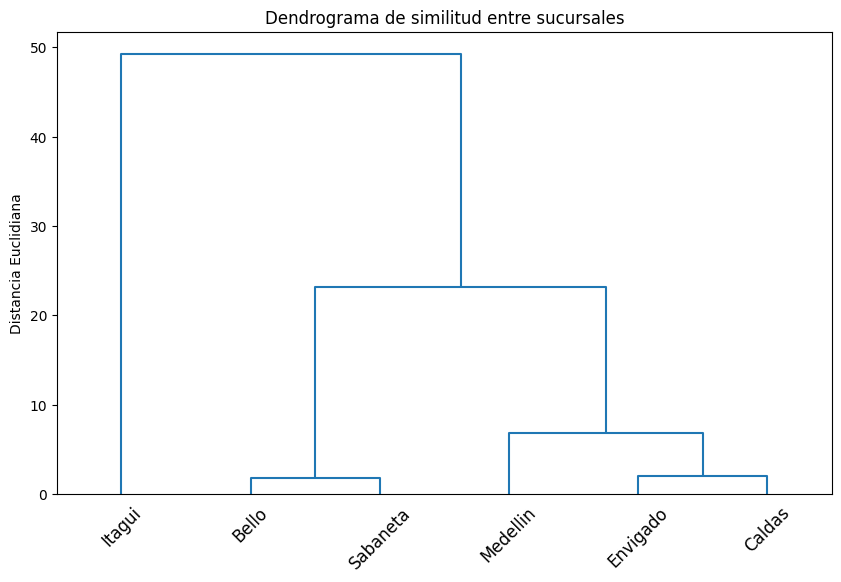

In [28]:
# Calcular linkage jerárquico
Z = linkage(sucursales_df, method='ward', metric='euclidean')

# Dibujar dendrograma
plt.figure(figsize=(10,6))
dendrogram(
    Z,
    labels=sucursales_df.index,
    leaf_rotation=45,
    leaf_font_size=12,
    color_threshold=0.5
)
plt.title("Dendrograma de similitud entre sucursales")
plt.ylabel("Distancia Euclidiana")
plt.show()

El dendrograma muestra el nivel de similitud entre las sucursales a partir del analisis de todas las variables. Se observa que Sabaneta presenta mayor similitud con la sucursal de Bello, ya que ambas se agrupan a una distancia muy baja. Por otro lado, Envigado y Caldas también forman un grupo muy cercano, al cual posteriormente se une Medellín. Finalmente, Itagüí es la sucursal más diferente, ya que se integra al grupo a una distancia mayor. En general, el análisis permite identificar qué sucursales tienen comportamientos más similares para facilitar la redistribución de pacientes tras el cierre de Sabaneta.

13. Visualización de redistribución de pacientes

/tmp/ipykernel_268/3014889607.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


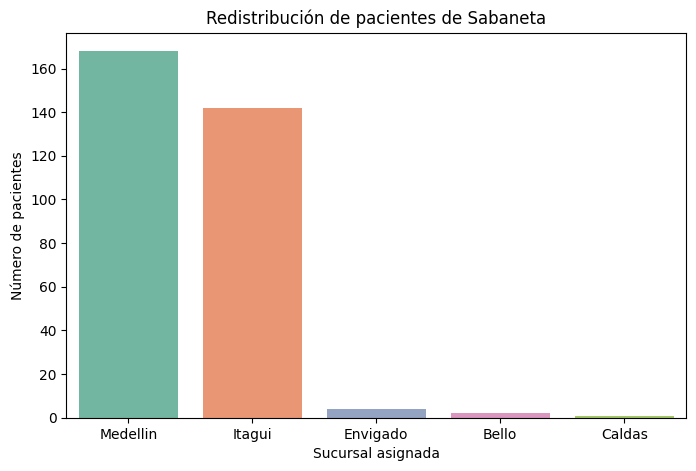

In [29]:
redistribucion = sabaneta_d["NuevaSucursal"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=redistribucion.index,
    y=redistribucion.values,
    palette="Set2"
)

plt.title("Redistribución de pacientes de Sabaneta")
plt.xlabel("Sucursal asignada")
plt.ylabel("Número de pacientes")

plt.show()

La redistribución de los pacientes de la sucursal de Sabaneta se realizó mediante el Método de Valor de Pertenencia, el cual asigna cada paciente a la sucursal con mayor similitud estadística en relación con las variables de referencia. Los resultados muestran una concentración significativa en las sedes de Medellin e Itagüí, lo que indica que estas sucursales presentan mayor afinidad con el perfil de pacientes de Sabaneta. En contraste, las demás sucursales recibieron una proporción mínima, reflejando una menor cercanía estadística. Este comportamiento confirma que la clasificación basada en pertenencia favorece la integración hacia las sedes con mayor compatibilidad, optimizando así la continuidad en la atención.


14. Comparación entre métodos

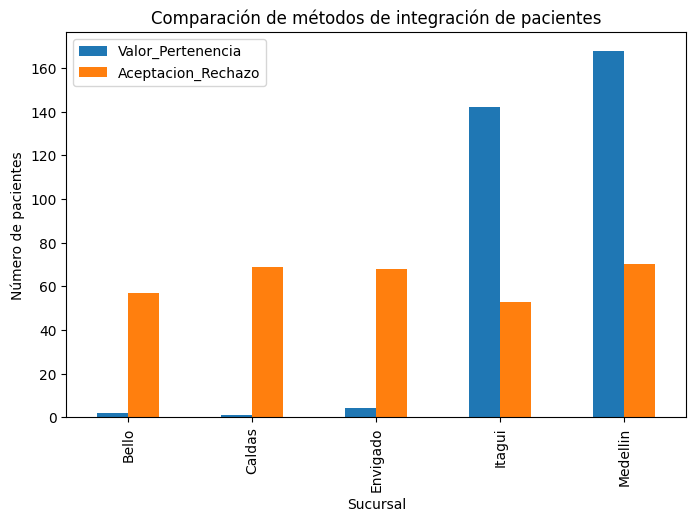

In [30]:
comparacion = pd.DataFrame({
"Valor_Pertenencia": sabaneta_d["NuevaSucursal"].value_counts(),
"Aceptacion_Rechazo": sabaneta_d["Sucursal_AR"].value_counts()
}).fillna(0)

comparacion.plot(kind="bar", figsize=(8,5))

plt.title("Comparación de métodos de integración de pacientes")
plt.xlabel("Sucursal")
plt.ylabel("Número de pacientes")

plt.show()

La comparación entre los métodos de Valor de Pertenencia y Aceptación y Rechazo evidencia diferencias significativas en la redistribución de pacientes. Mientras el primero concentra la mayoría en las sucursales de Medellin e Itagüí, reflejando mayor afinidad estadística con Sabaneta, el segundo ofrece una distribución más equilibrada, destacando Medellín como la sede con mayor asignación. Estos resultados muestran que el método de pertenencia prioriza la similitud clínica, mientras que el de aceptación y rechazo favorece la equidad operativa, brindando a la entidad criterios complementarios para la toma de decisiones.
